# World Cup 2026 — Exploratory Data Analysis
**Notebook 01** · Historical match results (1872–2026)

Goals of this notebook:
- Understand the shape and quality of the data
- Check for missing values and anomalies
- Answer basic football questions that inform model features
- Identify World Cup matches specifically

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
pd.set_option('display.max_columns', None)
print('Libraries loaded ✓')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded ✓


## 1. Load the Data

In [2]:
results = pd.read_csv('../data/raw/historical/results.csv')
goalscorers = pd.read_csv('../data/raw/historical/goalscorers.csv')
shootouts = pd.read_csv('../data/raw/historical/shootouts.csv')

print(f'results.csv      → {len(results):,} rows')
print(f'goalscorers.csv  → {len(goalscorers):,} rows')
print(f'shootouts.csv    → {len(shootouts):,} rows')

results.csv      → 49,477 rows
goalscorers.csv  → 47,747 rows
shootouts.csv    → 678 rows


## 2. Basic Sanity Checks

In [3]:
# Shape and columns
print('--- results.csv ---')
print(results.info())
print('\nFirst 5 rows:')
results.head()

--- results.csv ---
<class 'pandas.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  str    
 1   home_team   49477 non-null  str    
 2   away_team   49477 non-null  str    
 3   home_score  49453 non-null  float64
 4   away_score  49453 non-null  float64
 5   tournament  49477 non-null  str    
 6   city        49477 non-null  str    
 7   country     49477 non-null  str    
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB
None

First 5 rows:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
# Missing values
print('Missing values per column:')
print(results.isnull().sum())

# Date range
results['date'] = pd.to_datetime(results['date'])
print(f'\nDate range: {results["date"].min().year} → {results["date"].max().year}')

Missing values per column:
date           0
home_team      0
away_team      0
home_score    24
away_score    24
tournament     0
city           0
country        0
neutral        0
dtype: int64

Date range: 1872 → 2026


## 3. Tournament Breakdown

In [5]:
# What tournaments are in the dataset?
print('Top 20 tournaments by match count:')
print(results['tournament'].value_counts().head(20))

Top 20 tournaments by match count:
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64


In [6]:
# Isolate World Cup matches only
wc = results[results['tournament'] == 'FIFA World Cup'].copy()
print(f'Total World Cup matches in dataset: {len(wc)}')
print(f'World Cup editions covered: {wc["date"].dt.year.nunique()}')
wc.head()

Total World Cup matches in dataset: 1036
World Cup editions covered: 23


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True


## 4. Goals Analysis

In [7]:
# Average goals per game — all matches
results['total_goals'] = results['home_score'] + results['away_score']
print(f'Average goals per game (all matches): {results["total_goals"].mean():.2f}')
print(f'Average goals per game (World Cup only): {wc["home_score"].add(wc["away_score"]).mean():.2f}')

Average goals per game (all matches): 2.94
Average goals per game (World Cup only): 2.83


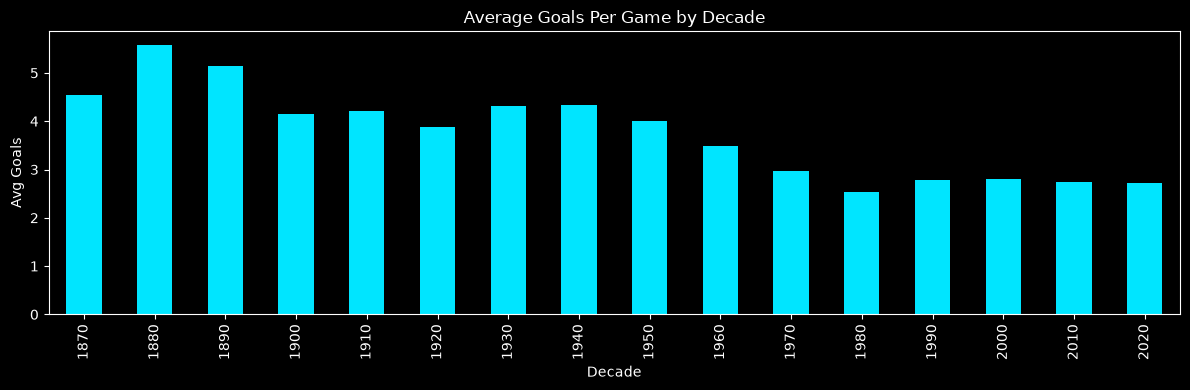

In [8]:
# Goals per decade — has the game changed?
results['decade'] = (results['date'].dt.year // 10) * 10
goals_by_decade = results.groupby('decade')['total_goals'].mean()

plt.figure(figsize=(12, 4))
goals_by_decade.plot(kind='bar', color='#00e5ff')
plt.title('Average Goals Per Game by Decade')
plt.xlabel('Decade')
plt.ylabel('Avg Goals')
plt.tight_layout()
plt.show()

## 5. Win / Draw / Loss Rates

In [9]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

results['result'] = results.apply(get_result, axis=1)
wc['result'] = wc.apply(get_result, axis=1)

print('--- All Matches ---')
print(results['result'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print('\n--- World Cup Only ---')
print(wc['result'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

--- All Matches ---
result
Home Win    49.0%
Away Win    28.2%
Draw        22.8%
Name: proportion, dtype: str

--- World Cup Only ---
result
Home Win    44.8%
Away Win    30.9%
Draw        24.3%
Name: proportion, dtype: str


## 6. Most Active Teams

In [10]:
# Teams with most international matches
home_counts = results['home_team'].value_counts()
away_counts = results['away_team'].value_counts()
total_matches = (home_counts.add(away_counts, fill_value=0)).sort_values(ascending=False)

print('Top 15 most active international teams:')
print(total_matches.head(15).astype(int))

Top 15 most active international teams:
home_team
Sweden         1104
England        1093
Argentina      1072
Brazil         1062
Germany        1034
South Korea    1010
Mexico         1006
Hungary        1006
Uruguay         973
France          938
Italy           893
Poland          892
Switzerland     887
Netherlands     882
Norway          875
Name: count, dtype: int64


## 7. Load 2026 Data

In [11]:
matches_2026 = pd.read_csv('../data/raw/wc2026/matches_detailed.csv')
players_2026 = pd.read_csv('../data/raw/wc2026/squads_and_players.csv')
elo = pd.read_csv('../data/raw/wc2026/elo_ratings_wc2026.csv')

print(f'2026 matches so far: {len(matches_2026)}')
print(f'Players registered: {len(players_2026)}')
print(f'Elo entries: {len(elo)}')

matches_2026.head()

2026 matches so far: 72
Players registered: 1248
Elo entries: 4683


,match_id,date,kickoff_time_utc,stage_name,stadium_name,city,country,home_team_name,home_fifa_code,away_team_name,away_fifa_code,home_score,away_score,status,home_xg,away_xg,home_goalkeeper,away_goalkeeper,player_of_the_match_name,referee_name
0,1,2026-06-11,19:00,Group Stage,Mexico City Stadium (Estadio Azteca),Mexico City,MEX,Mexico,MEX,South Africa,RSA,2.0,0.0,Completed,1.84,0.52,Francisco Guillermo Ochoa,Ronwen Hayden Williams,Julián Andrés Quinones,Szymon Marciniak
1,2,2026-06-11,23:00,Group Stage,Guadalajara Stadium (Estadio Akron),Zapopan,MEX,South Korea,KOR,Czechia,CZE,2.0,1.0,Completed,1.45,1.12,Seunggyu Kim,Mat ě j Kovar,Inbeom Hwang,Daniele Orsato
2,3,2026-06-12,19:00,Group Stage,Toronto Stadium (BMO Field),Toronto,CAN,Canada,CAN,Bosnia and Herzegovina,BIH,1.0,1.0,Completed,1.35,0.98,Maxime Crepeau,Nikola Vasilj,Ismaël Kenneth Jordan Kone,Michael Oliver
3,4,2026-06-12,23:00,Group Stage,Los Angeles Stadium (SoFi Stadium),Inglewood,USA,USA,USA,Paraguay,PAR,4.0,1.0,Completed,2.76,0.88,Matthew Charles Turner,Roberto Junior Fernandez,Folarin Jolaoluwa Balogun,Anthony Taylor
4,5,2026-06-13,15:00,Group Stage,Boston Stadium (Gillette Stadium),Foxborough,USA,Qatar,QAT,Switzerland,SUI,1.0,1.0,Completed,0.78,1.54,Ibrahim Mahmoud Abunada,Gregor Kobel,Ibrahim Mahmoud Abunada,Clément Turpin


## Next Steps
- [ ] Feature engineering notebook (form, head-to-head, Elo differential)
- [ ] Model training notebook (Win/Draw/Loss classifier)
- [ ] Monte Carlo simulation
- [ ] Player form scoring